In [243]:
import pandas as pd
import numpy as np
from hdr_adjustments import hdr_adjustment
import matplotlib.pyplot as plt
from skimage import io
from matplotlib.colors import ListedColormap, BoundaryNorm
from preprocess_point_cloud import preprocess_point_cloud
from pathlib import Path
from plot_tools import get_image_histogram, display_unwrapped_single_band_images, display_unwrapped_rgb_image
from norm_to_hsv import attach_normal_color_to_df

In [244]:
# Ignore warnings
pd.options.mode.chained_assignment = None  # Disable the warning

## Initialize Input Paths

In [245]:
key_str = "UMBCBL009_2024-03-28-00-35-40_AURSET3NorthU_060180_003712.800_1151376296"
key_str2 = "AURSET3"
output_dir = Path(f'/home/fzhcis/mylab/data/point_cloud_segmentation/unwrap_outputs/{key_str2}/{key_str}')
filename = output_dir / f'{key_str}_filtered_normaled.txt'
saveflag = True
upside_down = False # if the lidar was installed upside down; True for roots, False for tree trunk.


In [246]:
AZIMUTH_NORM_SCALE = 360
ZENITH_NORM_SCALE = 135
# Since degree resolution=0.25: 360/0.25=1440
CANVAS_WIDTH = 1440 
CANVAS_HEIGHT = 540

## Preprocess the Point Cloud data
- read the data as a pandas dataframe
- Clean it
  - Filter with first return and non-extreme intensity values
- prepare x_pix and y_pix columns for grouping

## Prepare the functions for displaying images.

### Observe the density map and histograms

In [247]:
def display_density_images(image_data: np.ndarray, saveflag: bool = False) -> None:
    """
    Display a density map image with a discrete colormap and optionally save the image.
    Parameters:
    -----------
    image_data : np.ndarray
        A 2D array representing the density of points per pixel.
    saveflag : bool, optional
        If True, the function will save the displayed image and the raw image data to the output_dir directory (default is False).
    Returns:
    --------
    None
    Notes:
    ------
    - The colormap used is 'jet' with the color for zero density set to black.
    - The colorbar is labeled with integer ticks corresponding to the density values.
    - If `saveflag` is True, two images are saved:
        1. 'Point Density Map raw.png' - the raw image data with the 'jet' colormap.
        2. 'Point Density Map.png' - the displayed image with a resolution of 600 dpi.
    """
    # Display the image with the discrete colormap
    fig = plt.figure(figsize=(12, 4))
    max_density = int(image_data.max())

    colors = plt.get_cmap('jet', max_density+1)(np.arange(max_density+1))
    colors[0] = [0, 0, 0, 1]  # Set the color for zero to black (RGBA)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, max_density+1.5, 1), cmap.N)  # Discrete boundaries at each integer
    
    plt.imshow(image_data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(ticks=range(max_density+1))  # Add colorbar with integer ticks
    cbar.set_ticklabels([str(i) for i in range(max_density+1)])  # Set labels to match each value
    cbar.set_label('Points per pixel')
    plt.title('Point Density Map')
    plt.show()

    if saveflag:
        plt.imsave(f'{output_dir}/Point Density Map raw.png', image_data, cmap=cmap)
        fig.savefig(f'{output_dir}/Point Density Map.png', dpi=600)
        print(f'Images saved to {output_dir} directory')


In [248]:
def unwrap_point_cloud_to_2d_images(filename: str, hdr_method: str = 'clahe', upside_down=True) -> tuple[pd.DataFrame, tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    """
    Unwrap the point cloud to 2D images with x being azimuth angle, y being zenith angle, and pixel value with different kinds of scalar fields.
    Including density, intensity, range, and range-xy images.

    Parameters:
    filename (str): The path to the point cloud data file in CSV format.
    hdr_method (str): The HDR adjustment hdr_method to apply. Default is 'clahe'.
    saveflag (bool): If True, save the images to the output_dir directory. Default is True.

    Returns:
    df_filtered (pd.DataFrame): A DataFrame containing the filtered and processed point cloud data with additional columns for pixel coordinates.
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]: A tuple containing the density image, adjusted intensity image, adjusted range image, and adjusted range-xy image.
    """
    # Step 5: Fill in the canvas pixels with scalar field values
    ## Preprocess the point cloud data
    df_filtered = preprocess_point_cloud(filename, upside_down=upside_down)
    df_filtered_ncolored = attach_normal_color_to_df(df_filtered)
    grouped = df_filtered_ncolored.groupby(['y_pix', 'x_pix'])

    ## Compute intensity and range per pixel. 
    ## Since less than 0.1% of the pixels contain more than one point, it doesn't matter if we use mean or max.
    group_intensity = grouped['Intensity'].mean()
    group_range = grouped['range1metres'].max()
    pts_per_pixel = grouped.size()
    z_value_per_pixel = grouped['Z'].mean().abs()
    # curvature_per_pixel = grouped['curvature'].mean()
    # roughness_per_pixel = grouped['roughness'].mean()
    
    range_x = grouped['X'].mean()
    range_y = grouped['Y'].mean()
    range_xy = np.sqrt(range_x**2 + range_y**2)

    ## Map the computed values to the image arrays
    ## Create empty image canvases with proper resolution
    z_value_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    intensity_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    range_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    range_xy_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)  # range in xy plane
    density_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    # curvature_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    # roughness_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    
    pxpy_indices = np.array(group_intensity.index.tolist())
    intensity_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_intensity.values
    range_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_range.values
    density_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = pts_per_pixel.values
    range_xy_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = range_xy.values
    z_value_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = z_value_per_pixel.values
    # curvature_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = curvature_per_pixel.values
    # roughness_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = roughness_per_pixel.values


    # Step 6: Apply HDR adjustment to intensity and range images
    intensity_image_adjusted = hdr_adjustment(intensity_image, method='clahe')
    range_image_adjusted = hdr_adjustment(range_image, method=hdr_method)
    range_xy_image_adjusted = hdr_adjustment(range_xy_image, method=hdr_method)
    z_value_image_adjusted = hdr_adjustment(z_value_image, method=hdr_method)
    # curvature_image_adjusted = hdr_adjustment(curvature_image, method=hdr_method)
    # roughness_image_adjusted = hdr_adjustment(roughness_image, method=hdr_method)

    output_images = (density_image, 
                     intensity_image_adjusted, 
                     range_image_adjusted, 
                     range_xy_image_adjusted, 
                     z_value_image_adjusted, 
                    #  curvature_image_adjusted,
                    #  roughness_image_adjusted,
                     intensity_image, 
                     range_image, 
                     range_xy_image, 
                     z_value_image,
                    #  curvature_image,
                    #  roughness_image,
                     )
   
    return df_filtered_ncolored, output_images


In [249]:
def unwrap_pc_normals_to_rgb_image(df_filtered_ncolored: pd.DataFrame) -> np.ndarray:
    """
    Unwrap the point cloud to 2D images with x being azimuth angle, y being zenith angle, and pixel values
    colorized by the normal vectors.

    Parameters:
    
    """
    grouped = df_filtered_ncolored.groupby(['y_pix', 'x_pix'])

    r_per_pixel = grouped['n_r'].mean()
    g_per_pixel = grouped['n_g'].mean()
    b_per_pixel = grouped['n_b'].mean()


    ## Map the computed values to the image arrays
    ## Create empty image canvases with proper resolution
    r_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    g_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    b_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    
    pxpy_indices = np.array(r_per_pixel.index.tolist())
    r_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = r_per_pixel.values
    g_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = g_per_pixel.values
    b_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = b_per_pixel.values

    # Stack the single channel images to create an RGB image
    rgb_image = np.stack((r_image, g_image, b_image), axis=-1) # Shape: (540, 1440, 3)
   
    return rgb_image

## Run the above process
- display density map and density histogram
- display Intensity Map, Range Map, and Range-XY Map

Header detected.


/home/fzhcis/mylab/tls_point_segmentation/norm_to_hsv.py:9: RuntimeWarning: invalid value encountered in arcsin
  elevation = np.arcsin(normals[:, 2])  # Angle relative to the Z-axis


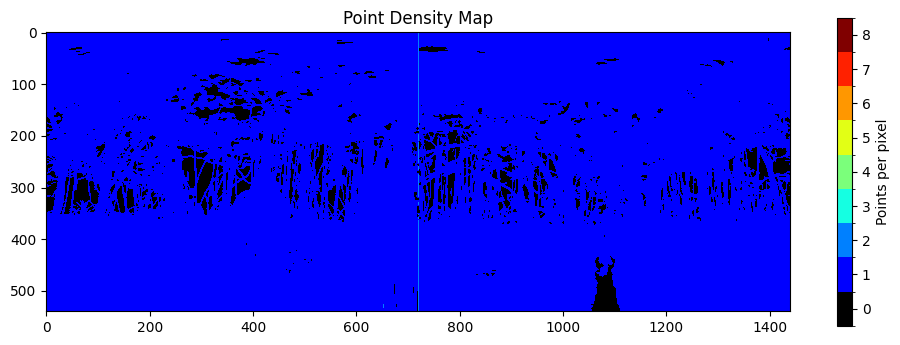

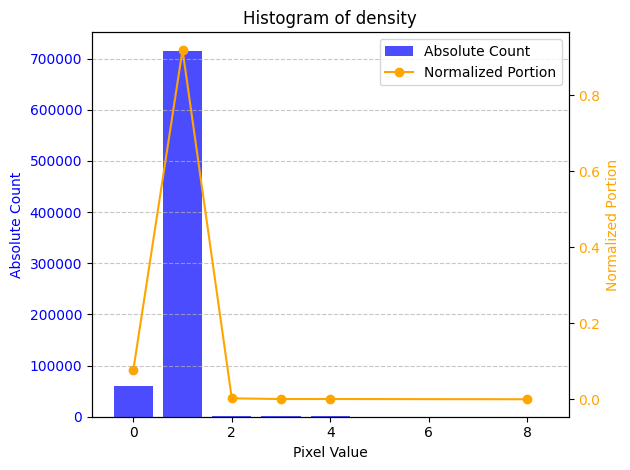

Histogram:
Values: [0. 1. 2. 3. 4. 8.]
Counts: [ 59231 715551   1878    448    491      1]
Normalized Counts: [0.076 0.92  0.002 0.001 0.001 0.   ]


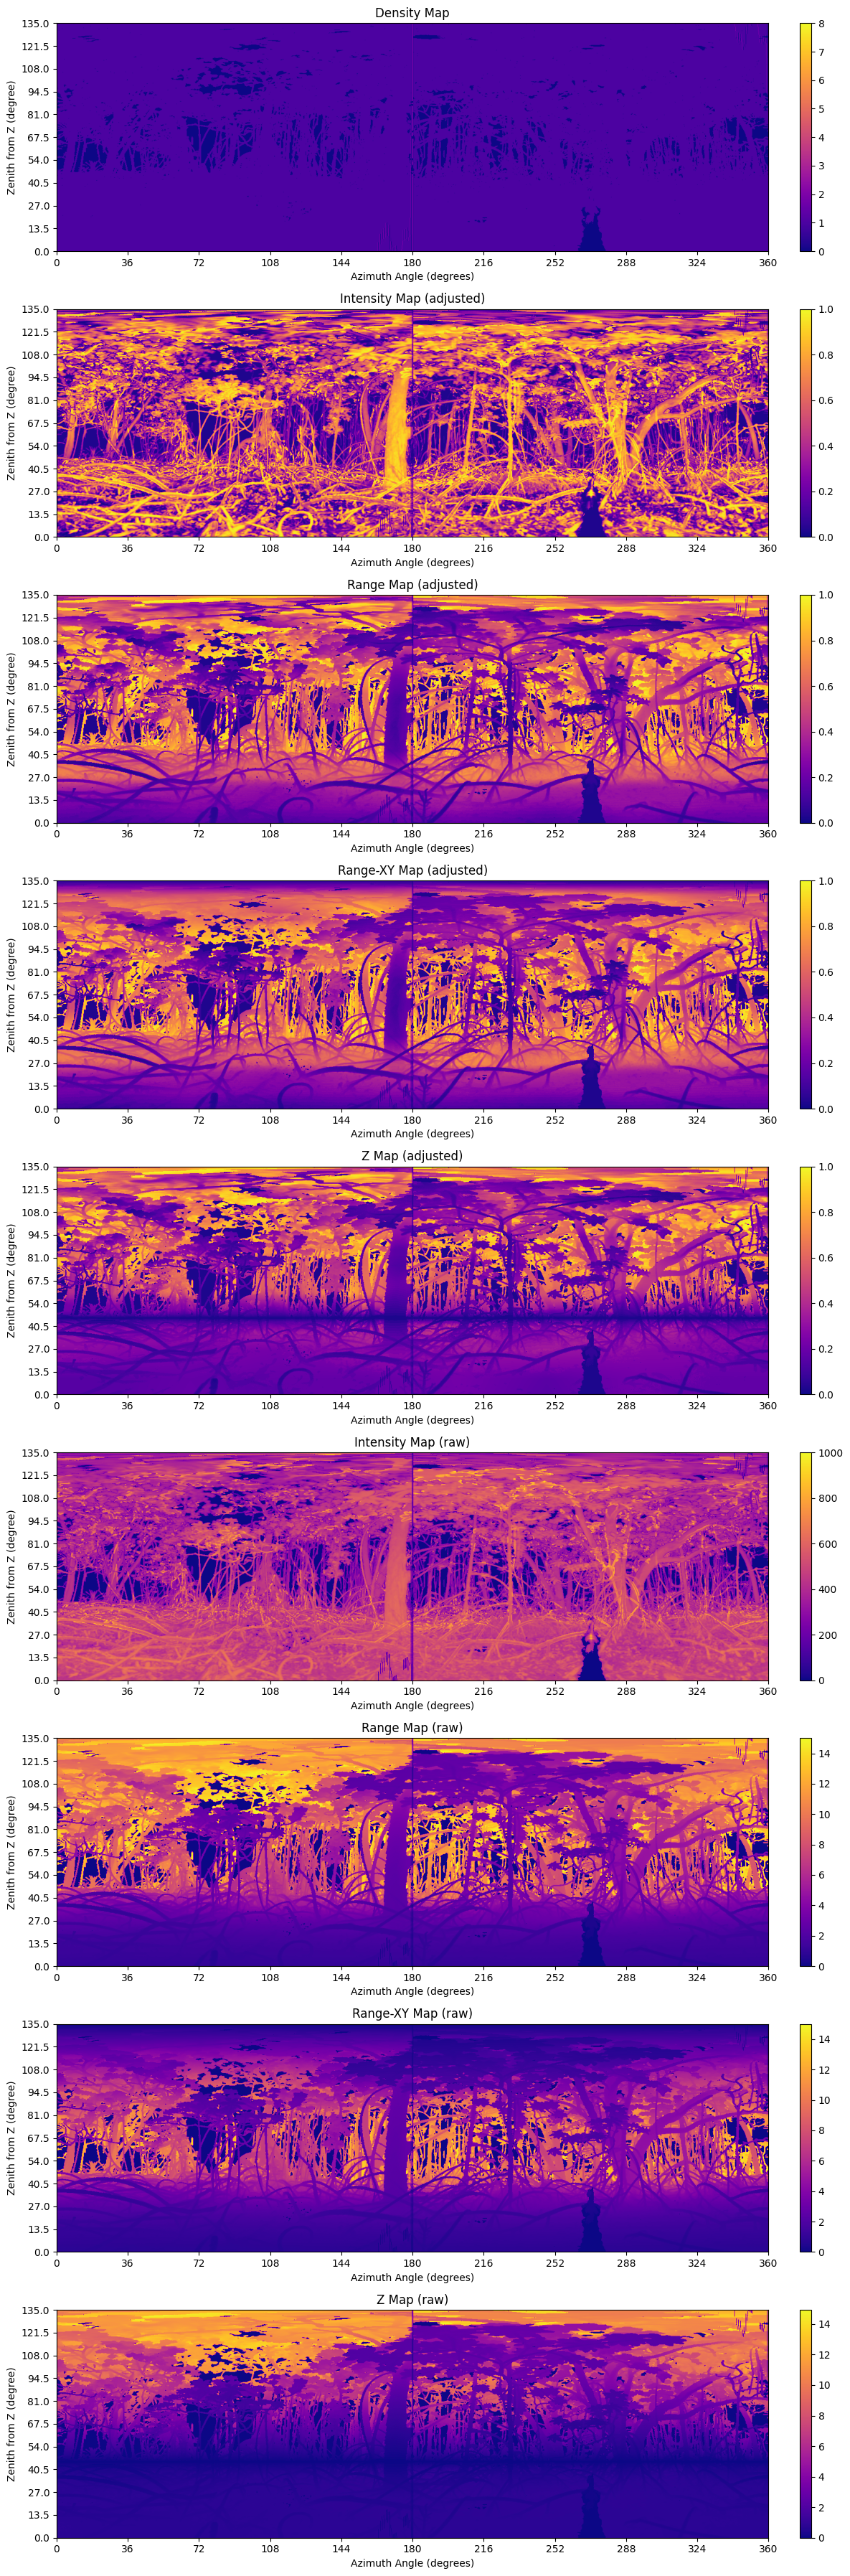

In [250]:
df_filtered, output_images = unwrap_point_cloud_to_2d_images(filename, hdr_method='clahe', upside_down=upside_down)
density_image = output_images[0]
titles = ['Density Map', 
          'Intensity Map (adjusted)', 
          'Range Map (adjusted)', 
          'Range-XY Map (adjusted)', 
          'Z Map (adjusted)', 
        #   'Curvature Map (adjusted)',
        #   'Roughness Map (adjusted)',
          'Intensity Map (raw)', 
          'Range Map (raw)', 
          'Range-XY Map (raw)', 
          'Z Map (raw)',
        #   'Curvature Map (raw)',
        #   'Roughness Map (raw)',
          ]
display_density_images(density_image, saveflag=False)
get_image_histogram(image_data=density_image, 
                    title='density', 
                    saveflag=False, 
                    output_dir=output_dir)


# Step 7: Display and save the adjusted intensity and range images
display_unwrapped_single_band_images(output_images, 
                                    titles=titles,
                                    output_dir=output_dir,
                                    saveflag=False)



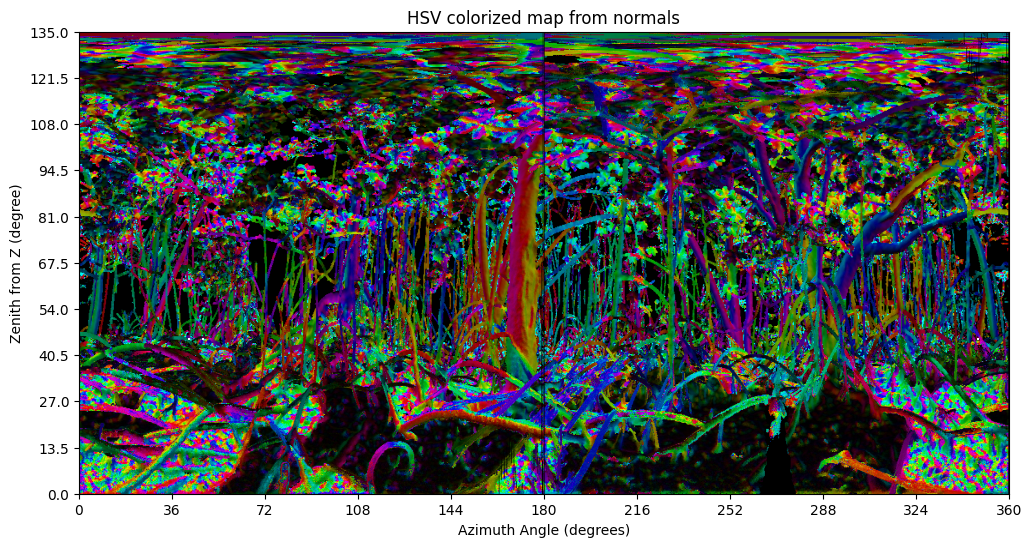

/home/fzhcis/mylab/tls_point_segmentation/plot_tools.py:227: RuntimeWarning: invalid value encountered in cast
  rgb_image_uint8 = (rgb_image * 255).astype(np.uint8)


In [251]:
# Display the normals colorized RGB image.
normals_rgb_image = unwrap_pc_normals_to_rgb_image(df_filtered)
display_unwrapped_rgb_image(normals_rgb_image, 
                            figure_title='HSV colorized map from normals', 
                            saveflag=saveflag, 
                            output_dir=output_dir)

In [252]:
# for hist_image, title in zip(output_images, titles):
#     get_image_histogram(image_data=hist_image, title=title, saveflag=False, output_dir=output_dir)

## Combine Unwrapped images to an psudo-RGB image

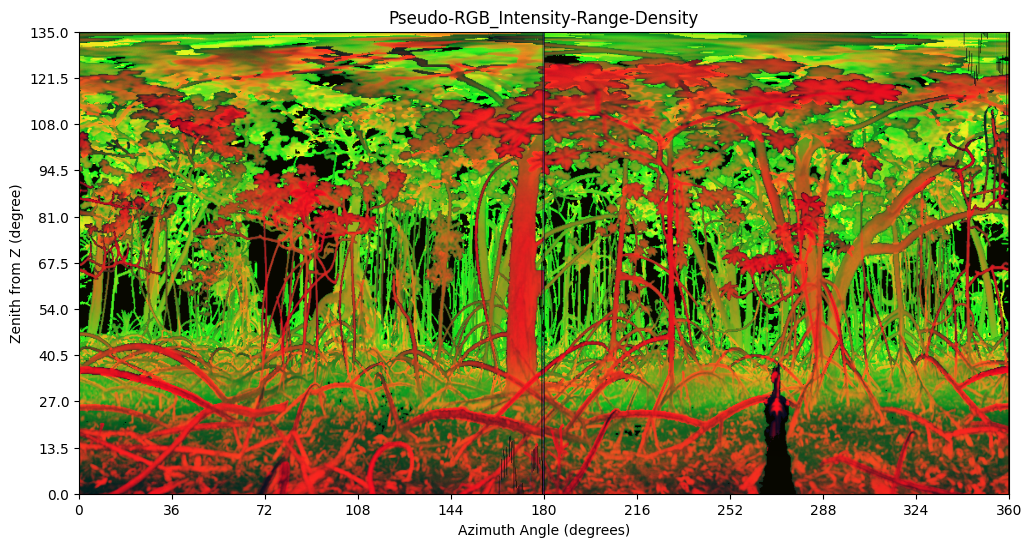

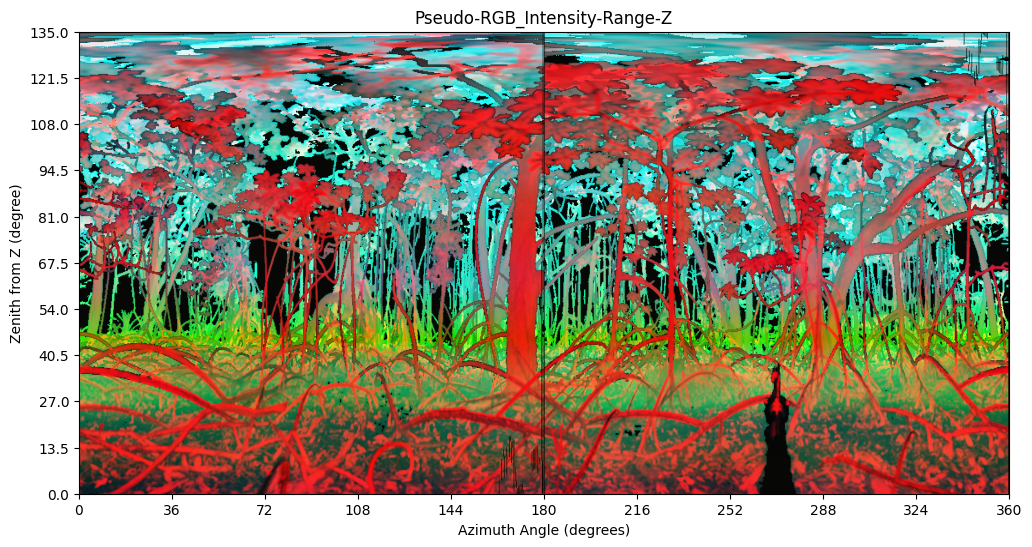

In [253]:
def create_pseudo_rgb_image(intensity_image: np.ndarray, 
                            range_image: np.ndarray, 
                            third_channel_img: np.ndarray, 
                            figure_title: str = '',
                            saveflag:bool=False) -> np.ndarray:
    """
    Combine intensity, range, and density images into a pseudo-RGB image.

    Parameters:
    -----------
    intensity_image : np.ndarray
        The adjusted intensity image.
    range_image : np.ndarray
        The adjusted range image.
    third_channel_img : np.ndarray
        The third channel image, can be the density map, z-value map, or any other scalar field.

    Returns:
    --------
    np.ndarray
        The pseudo-RGB image.
    """
    # Normalize the images to the range [0, 1]
    intensity_norm = (intensity_image - intensity_image.min()) / (intensity_image.max() - intensity_image.min())
    range_norm = (range_image - range_image.min()) / (range_image.max() - range_image.min())
    third_channel_img_norm = (third_channel_img - third_channel_img.min()) / (third_channel_img.max() - third_channel_img.min())

    # Stack the normalized images to create an RGB image
    # pseudo_rgb_image = np.stack((intensity_norm, range_norm, density_norm), axis=-1)
    pseudo_rgb_image = np.stack((intensity_norm, range_norm, third_channel_img_norm), axis=-1)

    # Display the pseudo-RGB image
    # Define custom ticks using np.linspace
    y_ticks = np.linspace(0, ZENITH_NORM_SCALE, CANVAS_HEIGHT + 1)
    x_ticks = np.linspace(0, AZIMUTH_NORM_SCALE, CANVAS_WIDTH + 1)
    plt.figure(figsize=(12, 6))
    plt.imshow(pseudo_rgb_image, aspect='auto', extent=[x_ticks[0], x_ticks[-1], y_ticks[0], y_ticks[-1]])
    
    plt.title(figure_title)
    plt.xticks(x_ticks[::int(len(x_ticks) / 10)])  # Reduce the number of x-ticks to avoid overlap
    plt.yticks(y_ticks[::int(len(y_ticks) / 10)])  # Reduce the number of y-ticks for readability
    plt.xlabel('Azimuth Angle (degrees)')
    plt.ylabel('Zenith from Z (degree)')
    plt.show()

    if saveflag:
        pseudo_rgb_image_uint8 = (pseudo_rgb_image * 255).astype(np.uint8)
        io.imsave(f'{output_dir}/{figure_title}.tif', pseudo_rgb_image_uint8)

    return pseudo_rgb_image

# Create the pseudo-RGB image
figure_title_1 = 'Pseudo-RGB_Intensity-Range-Density'
figure_title_2 = 'Pseudo-RGB_Intensity-Range-Z'
figure_title_3 = 'Pseudo-RGB_Intensity-Range-Curvature'
figure_title_4 = 'Pseudo-RGB_Intensity-Range-Roughness'
# density_image, intensity_image_adjusted, range_image_adjusted, z_value_image_adjusted, curvature_image_adjusted, roughness_image_adjusted = output_images[0], output_images[1], output_images[2], output_images[4], output_images[5], output_images[6]
density_image, intensity_image_adjusted, range_image_adjusted, z_value_image_adjusted = output_images[0], output_images[1], output_images[2], output_images[4]
pseudo_rgb_image_1 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, density_image, figure_title_1, saveflag=saveflag)
pseudo_rgb_image_2 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, z_value_image_adjusted, figure_title_2, saveflag=saveflag)
# pseudo_rgb_image_3 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, curvature_image_adjusted, figure_title_3, saveflag=saveflag)
# pseudo_rgb_image_4 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, roughness_image_adjusted, figure_title_4, saveflag=saveflag)

